**420-C74-SF - Techniques d'apprentissage automatique - Automne 2026 - Spécialiste en solutions d'intelligence artificielle**<br/>
© 2026 MKL.AI - Tous droits réservés
<br/>
![Atelier - Régression linéaire multiple](static/04-A-banner.png)
<br/>
**Objectif:** cette séance de travaux pratique consiste en la mise en oeuvre sous forme de code vectorisé de l'**algorithme du gradient en régression linéaire multiple**. Le jeu de données utilisé sera la version complète du jeu de données *Advertising* et devra être **mis à l'échelle**

In [30]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

### 0 - Chargement des bibliothèques

In [31]:
# Manipulation de données
import numpy as np
import pandas as pd
from collections import defaultdict

# Visualisation de données
import matplotlib.pyplot as plt
import seaborn as sns

# Outils divers
from tqdm.notebook import tqdm_notebook
from tqdm import tqdm

In [32]:
# Configuration de la visualisation
sns.set(style="darkgrid", rc={'figure.figsize':(11.7,8.27)})

### 1 - Lecture du jeu de données advertising

**Exercice 1-1**: à l'aide de la bibiothèques *pandas*, lire le fichier `advertising-multivariate.csv`

In [33]:
# Compléter le code ci-dessous ~ 1 ligne
df = pd.read_csv("/notebooks/data/advertising-multivariate.csv", usecols=["TV", "radio", "newspaper", "sales"])

**Exercice 1-2**: à l'aide de la fonction `head()`, visualiser les premières lignes de la trame de données. Quelle sera la taille du vecteur de paramètres $\theta$ ?

In [34]:
# Compléter le code ci-dessous ~ 1 ligne
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 2 - Mise à l'échelle des données

**Exercice 2**: Standardiser les données.<br/>
Note: Il n'est pas nécéssaire de standardiser la variable de sortie, mais vous pouvez le faire à des fins de simplification

In [35]:
# Compléter le code ci-dessous ~ 1 ligne
df_norm = (df - df.mean()) / df.std()
df_norm.head()

,TV,radio,newspaper,sales
0,0.967425,0.979066,1.774493,1.548168
1,-1.194379,1.080097,0.667903,-0.694304
2,-1.512360,1.524637,1.779084,-0.905135
3,0.051919,1.214806,1.283185,0.858177
4,0.393196,-0.839507,1.278593,-0.215143


### 3 - Préparation de la structure de données

**Exercice 3**: Construire la matrice des prédicteurs X sans oublier d'ajouter une colonne représentant $x_0$

In [36]:
# Compléter le code ci-dessous ~ 5 lignes
x0 = np.ones(len(df)) # On ajoute une colonne de 1 pour le biais
x1 = df_norm['TV'].values
x2 = df_norm['radio'].values
x3 = df_norm['newspaper'].values
X = np.column_stack((x0, x1, x2, x3)).T # On empile les colonnes pour former la matrice X

y = df['sales'].values # Nous gardons ici les valeurs non standardisée

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester la forme de `X`. Le `assert` ne doit pas renvoyer d'exception</strong>

In [37]:
assert X.shape == (4,200)

### 4 - Définition du modèle

**Exercice 4**: compléter la fonction ci-dessous représentant le modèle de régression linéaire multiple (hypothèse)

Pour rappel, le modèle de régression multiple est

$h_{\theta}(x)=\theta_{0}x_0 + \theta_{1}x_1 + \cdots + \theta_{n}x_n = \theta^TX$

In [38]:
def hypothesis(x, theta):
    assert x.shape[0] == theta.shape[0]
    # Compléter le code ~ 1 ligne
    h = np.dot(theta.T, x)
    return h

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre fonction `hypothesis`. Le `assert` ne doit pas renvoyer d'exception</strong>

In [39]:
x_test = np.array([[1,1],[3,4],[2,2],[1,-1]])
theta_test = np.array([1,2,2,4]).reshape(-1,1)
hypothesis(x_test, theta_test)
assert np.array_equal(hypothesis(x_test,theta_test), np.array([[15,9]]))

### 5 - Fonction de coût

**Exercice 5**: compléter la fonction ci-dessous permettant le calcul du coût (fonction de coût)

Pour rappel, la fonction de coût en régression linéaire multiple s'exprime sous la forme

$J(\theta)= \frac{1}{2m}\sum\limits_{i=1}^{m}(h_{\theta}(x^{(i)})-y^{(i)})^{2}=\frac{1}{2m}(y-X^t\theta)^T\times(y-X^t\theta)$

Remarque: comme le montre l'équation ci-dessus, il exite deux méthodes pour calculer la fonction de coût. Choisissez celle qui vous convient.<br/><em>Optionnel: faites l'autre méthode</em>

In [40]:
def cost_function(x,y, theta):
    # Compléter le code ~ 1-4 lignes
    m = X.shape[1]
    h = hypothesis(x, theta)
    cost = np.sum((h - y) ** 2) / (2 * m)
    return cost

<strong style='color: green'>TEST - Le code ci-dessous permet de tester la fonction `cost_function`. Celle-ci doit retourner un `numpy.float64`, c'est-à-dire un nombre et non tableau (array). Le `assert` ne doit pas renvoyer d'exception et le résultat attendu est ~ 94.92</strong>

In [41]:
theta_test = np.array([1,2,2,4]).reshape(-1,1)
cost = cost_function(X,y,theta_test)
assert type(cost) == np.float64
cost

np.float64(94.91820816343483)

### 6 - Algorithme du gradient

**Exercice 6**: Compléter l'algorithme du gradient ci-dessous. Choisir le vecteur $\theta$ initial, la valeurs du **pas** ($\alpha$) et le **nombre d'itérations**. Un test de convergence ne sera pas utilisé ici.

$
\text{Répéter pendant n_iterations}
\{\\
\theta_{j}:= \theta_{j} - \alpha\frac{1}{m}\sum\limits_{i=1}^{m}(h_{\theta}(x^{(i)})-y^{(i)})\times x_{j}^{(i)}\quad\forall j
\\
\}
$

Ou sous forme vectorisée:

$
\text{Répéter pendant n_iterations}
\{\\
\theta:= \theta - \alpha\frac{1}{m}(\theta^TX-y)\times X
\\
\}
$

<strong>Vous êtes vivement encouragés à utiliser la forme vectorisée. Celle-ci est de toute façon plus simple à coder que la version non vectorisée !</strong>

In [42]:
theta = np.random.randn(X.shape[0],1) # Initialisation aléatoire des paramètres
alpha = 0.01
n_iterations = 2000

m = y.shape[0]

history = defaultdict(list)

for i in tqdm(range(0, n_iterations)):
    
    # Compléter le code ~ 2 lignes
    gradient = (1 / m) * np.dot(X, (hypothesis(X, theta) - y).T)
    theta = theta - alpha * gradient

    #Tester la convergence de l'algorithme en comparant theta avec la solution exacte
    theta_exact = np.linalg.pinv(X @ X.T) @ X @ y
      
    # Sauvegarde des valeurs intermédiaires de theta et du coût
    if i%1 == 0:
        cost = cost_function(X, y, theta)
        history['theta_0'].append(theta[0])
        history['theta_1'].append(theta[1])
        history['theta_2'].append(theta[2])
        history['theta_3'].append(theta[3])
        history['cost'].append(cost)

print(history['theta_0'][-5:])
print(history['theta_1'][-5:])
print(history['theta_2'][-5:])
print(history['theta_3'][-5:],"\n")
print(history['cost'][-5:],"\n")

print("================================")
print(f'Theta exact = {theta_exact}')
print("================================")


print(f'Theta = {theta}')

100%|███████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 34224.27it/s]

[array([14.02249997]), array([14.02249997]), array([14.02249997]), array([14.02249997]), array([14.02249997])]
[array([3.92908866]), array([3.92908866]), array([3.92908866]), array([3.92908866]), array([3.92908866])]
[array([2.79906617]), array([2.79906619]), array([2.79906621]), array([2.79906623]), array([2.79906625])]
[array([-0.02259215]), array([-0.02259217]), array([-0.02259219]), array([-0.02259221]), array([-0.02259223])] 

[np.float64(1.392063157261315), np.float64(1.3920631572612399), np.float64(1.392063157261166), np.float64(1.3920631572610929), np.float64(1.3920631572610211)] 

Theta exact = [14.0225      3.92908869  2.79906919 -0.02259517]
Theta = [[14.02249997]
 [ 3.92908866]
 [ 2.79906625]
 [-0.02259223]]


Text(0.5, 0, 'Itérations')

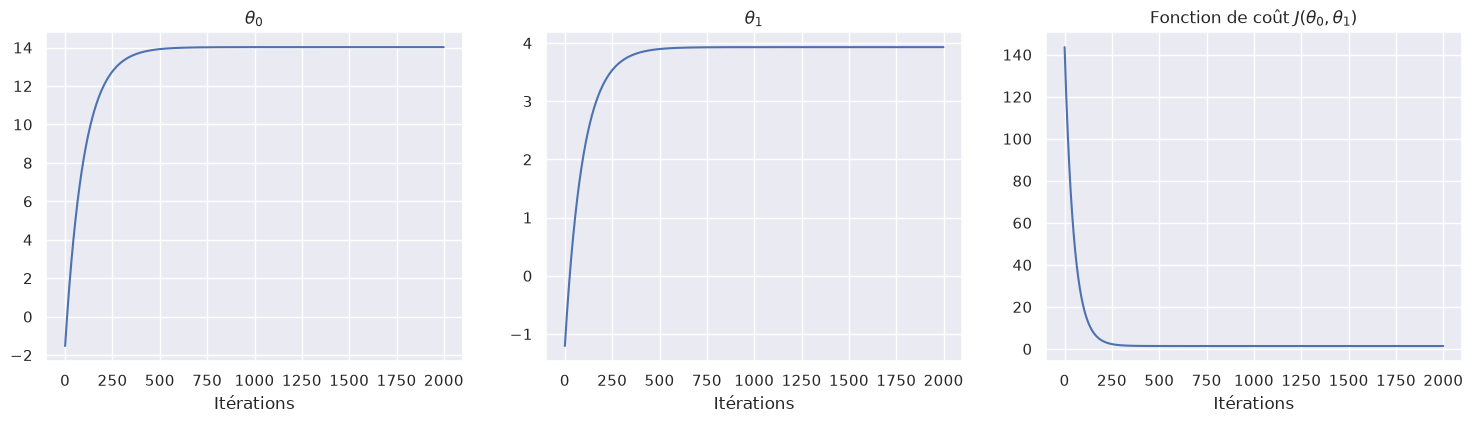

In [43]:
sns.set(rc={'figure.figsize':(18.27,4.27)})
f, (ax1, ax2, ax3) = plt.subplots(1, 3)
ax1.plot(history['theta_0'])
ax1.set_title(r'$\theta_{0}$')
ax1.set_xlabel('Itérations')
ax2.plot(history['theta_1'])
ax2.set_title(r'$\theta_{1}$')
ax2.set_xlabel('Itérations')
ax3.plot(history['cost'])
ax3.set_title(r'Fonction de coût $J(\theta_{0},\theta_{1})$')
ax3.set_xlabel('Itérations')

Les valeurs des paramètres $\theta_j$ devraient approcher


```
[[14.0225    ]
 [ 3.92908869]
 [ 2.79906919]
 [-0.02259517]]```

### 7 - Interprétation des paramètres

**Exercice 7**: Interpréter les paramètres obtenus

In [44]:
# θ0 = 14.0225   (biais/intercept)
# θ1 = 3.929     (TV)
# θ2 = 2.799     (radio)


### Fin de l'atelier